In [ ]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import scipy.optimize as optimize


import kwant
from scipy import linalg as la

from alter_morph.kwant_utilities import (
    crack_hamiltonian_for_contacts_kwant,
    attach_leads_to_cracked,
)

from scipy import linalg as la
from alter_morph.hamiltonians import alt_hamiltonian, spectral_function, _hopping_matrix

from tqdm import tqdm

import matplotlib

matplotlib.rcParams.update(
    {
        "font.size": 11,
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern"],
    }
)


def dos_at_fermi(energies, fermi_energy, broadening):
    norm_lorenzian = (1 / np.pi) * (
        broadening / ((energies - fermi_energy) ** 2 + broadening**2)
    )
    return np.mean(norm_lorenzian)

In [2]:
import sys, os

data_name = "data/full_phase_diagram_20_n_V0.pickle"

with open(data_name, "rb") as f:
    data = pickle.load(f)
with open("analysis/voronoi_20.pickle", "rb") as f:
    lattice = pickle.load(f)

In [3]:
fillings = data["filling"]
J_vals = data["J"]


avg_mags = np.zeros([len(fillings), len(J_vals)])
energies = np.zeros([len(fillings), len(J_vals), lattice.n_vertices * 4])

for i, filling in enumerate(tqdm(fillings)):
    for j, J in enumerate(J_vals):

        current_data = data["params"][i, j]

        avg_mags[i, j] = np.mean(current_data["m"])

        ham = alt_hamiltonian(
            lattice,
            current_data["t1"],
            current_data["t2"],
            current_data["J"],
            current_data["U"],
            current_data["m"],
            current_data["n"],
        )

        energies[i, j] = la.eigvalsh(ham)


data["params"][0, 0].keys()

100%|██████████| 31/31 [19:35<00:00, 37.93s/it]


dict_keys(['t1', 't2', 'J', 'U', 'filling', 'theta_offset', 'm', 'n'])

In [7]:
broadening = 0.01
dos_vals = np.zeros([len(fillings), len(J_vals)])
bond_diff_m = np.zeros([len(fillings), len(J_vals)])
bond_diff_n = np.zeros([len(fillings), len(J_vals)])

# size in MB

for i, filling in enumerate(tqdm(fillings)):
    for j, J in enumerate(J_vals):

        # dos at fermi level
        e = energies[i, j]
        fermi_energy = np.mean(e[int(filling * len(e)) - 1 : int(filling * len(e)) + 1])
        dos_vals[i, j] = dos_at_fermi(e, fermi_energy, broadening).real

        # difference in m on bonds
        m = data["params"][i, j]["m"]
        m_on_bonds = m[lattice.edges.indices]
        bond_diff_m[i, j] = np.abs(m_on_bonds[:, 0] - m_on_bonds[:, 1]).mean()

        # difference in n on bonds
        n = data["params"][i, j]["n"]
        n_on_bonds = n[lattice.edges.indices]
        bond_diff_n[i, j] = np.abs(n_on_bonds[:, 0] - n_on_bonds[:, 1]).mean()


J, FIL = np.meshgrid(J_vals, fillings)
print(FIL.shape, J.shape, avg_mags.shape, dos_vals.shape)

  0%|          | 0/31 [00:00<?, ?it/s]/opt/homebrew/Caskroom/miniforge/base/envs/kwant-test/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/homebrew/Caskroom/miniforge/base/envs/kwant-test/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
100%|██████████| 31/31 [00:00<00:00, 672.58it/s]

(31, 41) (31, 41) (31, 41) (31, 41)


/var/folders/v4/z7wcc4gj6clczcj6vr8b9dvw0000gn/T/ipykernel_46214/3829969583.py:32: MatplotlibDeprecationWarning:

Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).



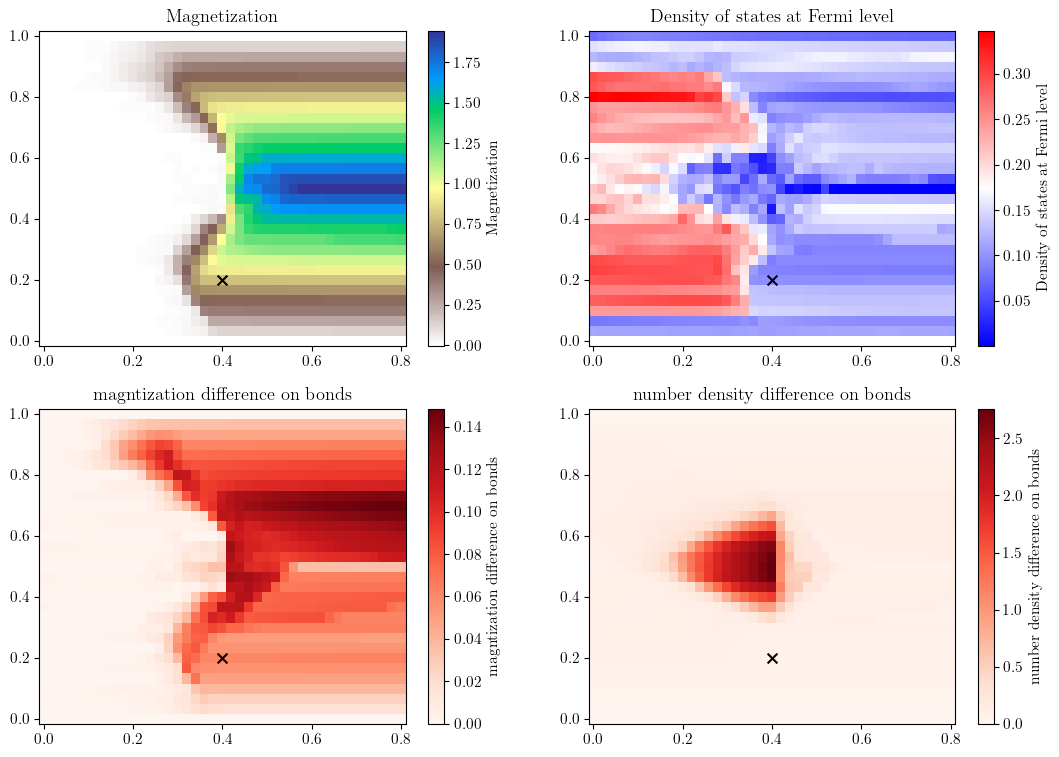

In [117]:
point_to_explore = (0.4, 0.2)
j_explore = np.argmin(np.abs(J_vals - point_to_explore[0]))
f_explore = np.argmin(np.abs(fillings - point_to_explore[1]))

fig, ax = plt.subplots(2, 2, figsize=(13, 9))
ax = ax.flatten()

for a in ax:
    a.scatter(
        J_vals[j_explore],
        fillings[f_explore],
        color="k",
        s=50,
        marker="x",
        zorder=10,
    )

im0 = ax[0].pcolor(J, FIL, avg_mags, cmap="terrain_r")
ax[0].set_title("Magnetization")

im1 = ax[1].pcolor(J, FIL, dos_vals, cmap="bwr")
ax[1].set_title("Density of states at Fermi level")

im2 = ax[2].pcolor(J, FIL, bond_diff_m, cmap="Reds")
ax[2].set_title("magntization difference on bonds")

im3 = ax[3].pcolor(J, FIL, bond_diff_n, cmap="Reds")
ax[3].set_title("number density difference on bonds")

# add colorbars
cbar0 = fig.colorbar(im0, ax=ax[0])
cbar1 = fig.colorbar(im1, ax=ax[1])
cbar2 = fig.colorbar(im2, ax=ax[2])
cbar3 = fig.colorbar(im3, ax=ax[3])

cbar0.set_label("Magnetization")
cbar1.set_label("Density of states at Fermi level")
cbar2.set_label("magntization difference on bonds")
cbar3.set_label("number density difference on bonds")

plt.savefig("phase_diag.pdf")
plt.show()

Now we can check a single point and look at the state of the system there. 

Start by converging a bit more for <3 accuracy

In [118]:
from alter_morph.mean_field import hartree_fock
from alter_morph.hamiltonians import alt_hamiltonian

parameters_at_point = data["params"][f_explore, j_explore]
parameters_for_run = {
    "t1": parameters_at_point["t1"],
    "t2": parameters_at_point["t2"],
    "J": parameters_at_point["J"],
    "U": parameters_at_point["U"],
    "filling": parameters_at_point["filling"],
    "initial_m": parameters_at_point["m"],
    "initial_n": parameters_at_point["n"],
    "theta_offset": 0,
}

# first check how converged we are
m_new, n_new = hartree_fock(
    lattice, parameters_for_run, 100, adjust_learning_rate=False
)

Avg:0.75, diff: 0.000001:  32%|███▏      | 32/100 [00:58<02:04,  1.84s/it]


In [134]:
hamiltonian = alt_hamiltonian(
    lattice,
    parameters_for_run["t1"],
    parameters_for_run["t2"],
    parameters_for_run["J"],
    parameters_for_run["U"],
    m_new[-1],
    n_new[-1],
    add_energy_shift=True,
)
energies, states = la.eigh(hamiltonian)

In [ ]:
fermi_energy = np.mean(
    energies[
        int(parameters_at_point["filling"] * len(energies))
        - 1 : int(parameters_at_point["filling"] * len(energies))
        + 1
    ]
)

In [ ]:
lead_onsite = np.mean(
    [
        hamiltonian[i * 4 : (i + 1) * 4, i * 4 : (i + 1) * 4]
        for i in range(lattice.n_vertices)
    ],
    axis=0,
)
lead_onsite = -np.eye(4)
lead_coupling = np.kron(np.eye(2), _hopping_matrix(1, 0.5, 0))

contact_lattice, k_lattice, k_system, contact_vertices = (
    crack_hamiltonian_for_contacts_kwant(lattice, hamiltonian)
)
kwant_system_with_leads, left_lead, right_lead = attach_leads_to_cracked(
    contact_lattice,
    k_lattice,
    k_system,
    contact_vertices,
    lead_onsite,
    lead_coupling,
    np.diag([-1, -1, 1, 1]),
)

k_system_f = k_system.finalized()

smatrix = kwant.smatrix(k_system_f, energy=fermi_energy)
g = np.array(
    [[smatrix.transmission((1, j), (0, i)) for j in range(2)] for i in range(2)]
)

conductance = g[0, 0] + g[1, 1]
spin_conductance = g[0, 0] - g[1, 1]

print("Conductance: ", conductance)
print("Spin conductance: ", spin_conductance)
g

Conductance:  1.9288600307049557
Spin conductance:  -0.8422428081558784


array([[0.54330861, 0.        ],
       [0.        , 1.38555142]])